#### **Sparse Autoencoder**

It is a kind of autoencoder that performs the following:--

    (a.)  adds a sparsity constraint

    (b.)  forces most of the neurons to be zero

    (c.)  learns all the meaningful features from the image by creating a sparse representation of the input features.


#### **Steps used in the Algorithm**


1. Import all the necessary Libraries

2. Load the dataset

3. Do Data Preprocessing and normalize the data

4. Flatten Images

5. Model Architecture and build the Sparse Autoencoder model

6. Compile the Sparse Model

7. Train the Sparse Model

8. Evaluate the Sparse model

9. Plot the accuracy vs loss

10. Reconstruct Images Using the Trained Model

11. Visualize Original vs Reconstructed Images

#### **Step 1: Import all the necessary Libraries**

In [268]:
import  numpy             as  np
import  pandas            as  pd
import  matplotlib.pyplot as  plt
import  seaborn           as  sns

from    tensorflow.keras.datasets   import mnist
from    tensorflow.keras.models     import Sequential
from    tensorflow.keras.layers     import Dense,Dropout,Flatten,BatchNormalization
from    tensorflow.keras.optimizers import Adam
from    tensorflow.keras            import regularizers

#### **OBSERVATIONS**

1. mnist --------->  It is the dataset that represents the handwritten digits

2.  Sequential -----> It is a sequential model with linear stack of layers

3.  Dense -------> fully dense connected layers

4.  Dropout -----> prevents the overfitting

5.  Flatten ------> 2d or 3d feature maps into 1 d vectors

6.  BatchNormalization ----> speeds up the training process

7.  Adam ------> updates the weights during backpropogation

8.  regularizers ------>  It prevents the autoencoder to directly copy the input to the output rather than learning all the compressed and meaningful representations of the input.

#### **STEP 2: Load the dataset**

In [269]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [270]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [271]:
X_test

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [272]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (60000, 28, 28)
Shape of the input testing  data is: (10000, 28, 28)


In [273]:
Y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [274]:
Y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [275]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (60000,)
Shape of the output testing  data is: (10000,)


#### **OBSERVATIONS:**

1. The mnist handwritten digits dataset is loaded .

2. Then this dataset is divided into training and testing data

3. The input training data has 60000 input training labels with 28 * 28 pixels

4. The input testing data has 10000 input testing labels with 28 * 28 pixels

5. In the Autoencoder, we have only inputs and no outputs as Autoencoder is an example of unsupervised learning.

#### **Step 3: Do Data Preprocessing and normalize the data**

In [276]:
#### Data Preprocessing and normalizing the data
X_train = X_train.astype('float32')/255.0

In [277]:
X_train

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [278]:
X_test = X_test.astype('float32')/255.0

In [279]:
X_test

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

#### **OBSERVATIONS:**

1. After performing the normalization on the input pixel values, the pixel values get scaled from 0 to 255 till 0 to 1.

2. This normalization is performed because the neural network model can only work with the normlaized input data.

#### **Step 4: Flatten Images**

In [280]:
#### Dimension of the input data
print("Dimension  of the input training data before reshaping is:", X_train.ndim)
print("Dimnension of the input testing  data before reshaping is:", X_test.ndim)

Dimension  of the input training data before reshaping is: 3
Dimnension of the input testing  data before reshaping is: 3


In [281]:
#### Shape of the input data
print("Shape      of the input training data before reshaping is:", X_train.shape)
print("Shape      of the input testing  data before reshaping is:", X_test.shape)

Shape      of the input training data before reshaping is: (60000, 28, 28)
Shape      of the input testing  data before reshaping is: (10000, 28, 28)


In [282]:
#### Flatten the input imags
X_train = X_train.reshape(len(X_train),784)
X_test  = X_test.reshape(len(X_test),784)

In [283]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [284]:
X_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [285]:
#### Dimension of the input data
print("Dimension  of the input training data after reshaping is:", X_train.ndim)
print("Dimnension of the input testing  data after reshaping is:", X_test.ndim)

Dimension  of the input training data after reshaping is: 2
Dimnension of the input testing  data after reshaping is: 2


In [286]:
#### Shape of the input data
print("Shape      of the input training data after  reshaping is:", X_train.shape)
print("Shape      of the input testing  data after  reshaping is:", X_test.shape)

Shape      of the input training data after  reshaping is: (60000, 784)
Shape      of the input testing  data after  reshaping is: (10000, 784)


#### **OBSERVATIONS:**

1.  Here the input training data is of the form (60000,28,28)

2.  After performing the flattening operation it is converted into (60000,784)

3.  Here the input testing data is of the form (10000,28,28)

4.  After performing the flattening operation it is converted into (10000,784)

5. Now both the input training and testing data has the input in form of 2d because the fully dense connected layer expects the input to be in form of 2D.

#### **Step 5: Model Architecture and build the Sparse Autoencoder model**

In [287]:
#### Construct the sparse autoencoder model
model = Sequential([
    ######################### Encoder ######################################################
    #### create the first dense layer
    Dense(units=128,activity_regularizer=regularizers.L1(1e-5),activation='relu',input_shape=(784,)),
    #### create the second dense layer
    Dense(units=64,activity_regularizer=regularizers.L1(1E-5),activation='relu'),


    ######################### Decoder ######################################################
    Dense(units=128,activation='relu'),
    Dense(units=784,activation='sigmoid')
])

In [288]:
model

<Sequential name=sequential_6, built=True>

#### **OBSERVATIONS:**

1.  The sparse autoencoder model is created with the following layers

    (a.)  Encoders

        It plays a main role in learning all the compressed representation of the input.

        (i) The first dense layer is created with 28*28 input images.

        (ii) Here relu activation function is applied to increase the non-linearity of the image.

        (iii) activity regularizers = l1 is used

              (a.) to prevent the model from memorizing the entire input

              (b.) to learn all the compressed representations of the input

              (c.) transform the input and get the output activation of the neuron

              (d.) improve the convergence speed.

              (e.) l1 is used to prevent the overfitting.

        (iv)  The input features of 784 is compressed to 128

        (v)  Then again the second dense layer is formed where the input features of 128 is compreesed to 64 features.

     (b.) Decoder

        (i) Then original image is reconstructed and largerd from 64 ---> 128 features

        (ii) Again the image is reconstructed back to the original form from 128 --> 784 features

#### **Step 6: Compile the Sparse Model**

In [289]:
#### compile the model
model.compile(
    optimizer  =  'adam'                                           ,
    loss       =  'binary_crossentropy'                            ,
    metrics    =  ['accuracy']
)

#### **OBSERVATIONS:**

1.  The model has been made ready for the training purpose with the help of the following parameters:-

	(a.) optimizer = 'adam' . It is used to make the learning rate as dynamic and improves the convergence speed.

	(b.) loss = 'binary_crossentropy'. It is a binary loss function as it is used to solve the binary classification problem.

	(c.) metrics = 'accuracy'. It is used to evaluate the performance of the model

#### **Step 7: Train the Sparse Model**

In [290]:
#### Train the model
history = model.fit(
    X_train                          ,
    X_train                          ,
    epochs           =    10         ,
    batch_size       =    256        ,
    validation_split =    0.2        ,
    verbose          =    1
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.0113 - loss: 0.3648 - val_accuracy: 0.0088 - val_loss: 0.2594
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.0115 - loss: 0.2471 - val_accuracy: 0.0097 - val_loss: 0.2343
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0096 - loss: 0.2242 - val_accuracy: 0.0128 - val_loss: 0.2137
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0128 - loss: 0.2057 - val_accuracy: 0.0092 - val_loss: 0.1993
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.0086 - loss: 0.1930 - val_accuracy: 0.0093 - val_loss: 0.1874
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.0098 - loss: 0.1836 - val_accuracy: 0.0121 - val_loss: 0.1813
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.0103 - loss: 0.1778 - val_accuracy: 0.0112 - val_loss: 0.1757
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.0108 - loss: 0.1729 - val_acc

In [291]:
history

#### **OBSERVATIONS:**

1. The sparse autoencoder model has been trained with the help of the following parameters:-

(a.) training data ----------------> X_train, X_train

.   X_train       ------->  input image     (input)

.   X_train       ------->  output image  (output)  as this algorithm doe not have any output

2.  It has the  image as the input, performs the encoding and then reconstructs the original image from it as the output.

Then the reconstructed image is compared with the original image.

(b.) epochs = 10 ------------> 10 iterations are needed to train the model

(c.) batch_size = 256 -------> the weights get updated after every 256 samples

(d.) validation_split = 0.2 --------> 20 % of the data is used for validation where the model sees the performance on the unseen data

#### **Step 8: Evaluate the Sparse model**

In [292]:
#### evaluate the model
loss, accuracy = model.evaluate(X_test,X_test,verbose=0)

print(f"Loss is : {loss:.4f}")
print(f"Accuracy is : {accuracy:.4f}")

Loss is : 0.1510
Accuracy is : 0.0138


#### **Step 9: Plot the accuracy vs loss**

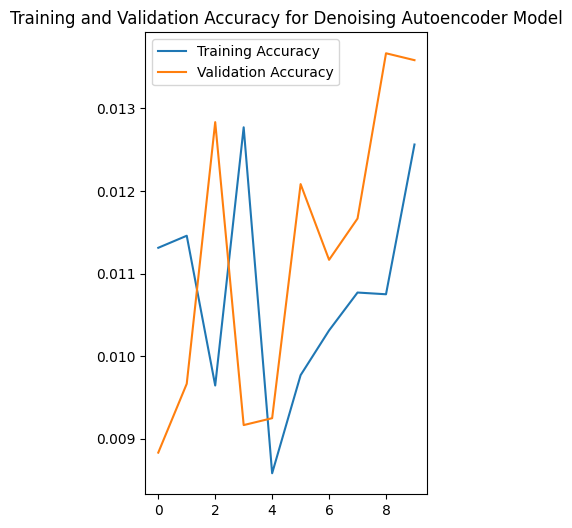

In [293]:
plt.figure(figsize=(8,6))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy for Denoising Autoencoder Model')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1. With the increase in the number of epochs, the accuracy and the validation accuracy of the model increases.

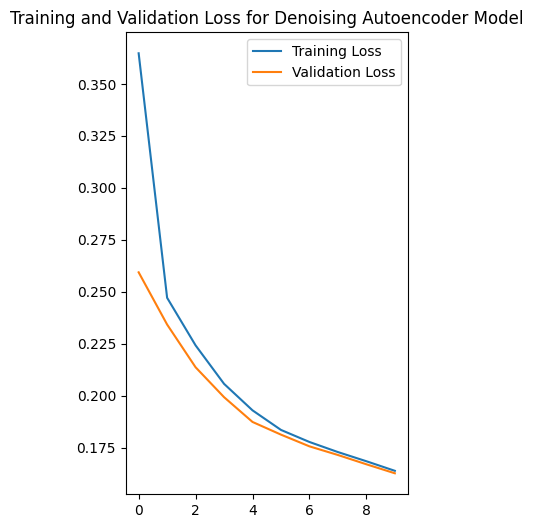

In [294]:
plt.figure(figsize=(8,6))
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Training and Validation Loss for Denoising Autoencoder Model')
plt.legend()
plt.show()

#### **OBSERVATIONS:**

1. With the increase in the number of epochs, the accuracy and the validation accuracy of the model decreases.

#### **Step 10: Reconstruct Images Using the Trained Model**

In [295]:
#### predict the output
decoded_imgs = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [297]:
decoded_imgs

array([[1.5452157e-07, 1.0382166e-07, 8.5386212e-08, ..., 1.7283411e-07,
        1.7378545e-07, 1.6148381e-07],
       [6.1169777e-07, 7.8880493e-07, 4.9062186e-07, ..., 6.6690126e-07,
        5.7205943e-07, 5.6181551e-07],
       [1.8113543e-10, 1.1918870e-10, 8.6293285e-11, ..., 2.1870286e-10,
        9.7727923e-11, 1.3045282e-10],
       ...,
       [1.4357495e-07, 9.4560811e-08, 1.4487513e-07, ..., 1.1388147e-07,
        1.1140351e-07, 1.9126631e-07],
       [1.2035019e-05, 1.1195212e-05, 1.5400892e-05, ..., 1.2832844e-05,
        1.0356090e-05, 1.4093127e-05],
       [2.7127912e-08, 3.9321410e-08, 4.7766495e-08, ..., 1.8801206e-08,
        3.1881871e-08, 3.3870428e-08]], dtype=float32)

#### **OBSERVATIONS**

1.  The output is predicted

#### **Step 11: Visualize Original vs Reconstructed Images**

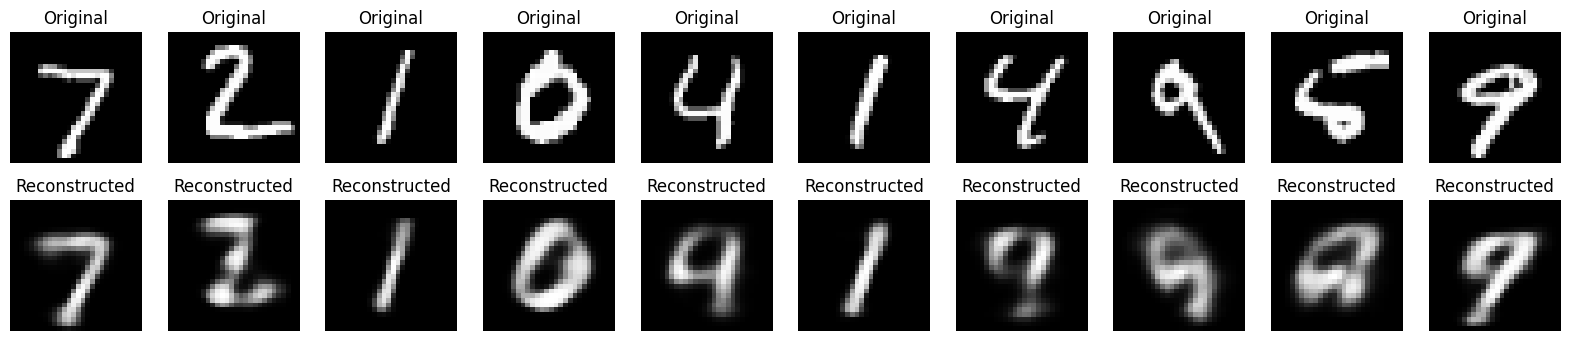

In [296]:
n = 10  # Show 10 images
plt.figure(figsize=(20,4))

for i in range(n):
    # Display original  input image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")
    ax.set_title("Original")
    plt.axis("off")

    # Display reconstructed input  image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    ax.set_title("Reconstructed")
    plt.axis("off")

plt.show()



#### **OBSERVATIONS:**

1. Here we have performed the visualization between the Original image vs Reconstructed image.

2. We have made the comparision between the two and came to the conclusion that both the images looks the same after performing the above algorithm.

3. So the Sparse Autoencoder is working fine